# **Pretraining on Unlabeled Data**

This section covers;

- Computing the training and validation set losses to assess the quality of LLM generated text during training.

- Implementing a training function and pretraining the LLM.

- Saving and loading `model weights` to continue training an LLM.

- Loading pretrained weights from `OpenAI`.

In [1]:
from importlib.metadata import version

pkgs = ["matplotlib", 
        "numpy", 
        "tiktoken", 
        "torch",
        "tensorflow" # For OpenAI's pretrained weights
       ]
for p in pkgs:
    print(f"{p} version: {version(p)}")

matplotlib version: 3.10.6
numpy version: 1.26.4
tiktoken version: 0.11.0
torch version: 2.4.0
tensorflow version: 2.20.0


- The core focus of this section is to implement a training
function and pretrain the LLM.

![Alt text](../../assests/figure51.png)

- The figure above provides a mental model of the three main stages of coding an LLM, pretraining the LLM on a general text dataset and finetuning it on a labeled dataset. 

- This section focuses on pretraining the LLM, which includes implementing the training code, evaluating the performance, and saving and loading model weights.

- Understand and learn about basic model evaluation techniques to measure the quality of the generated text, which is a requirement for optimizing the LLM during the training process. 

## **1. Evaluating generative text models**


![Alt text](../../assests/figure52.png)

- We start this section with a brief recap of initializing a GPT model using the code from the previous chapter

- Then, we discuss basic evaluation metrics for LLMs

- Lastly, in this section, we apply these evaluation metrics to a training and validation dataset



**Using GPT to generate text**

In [2]:
import torch
from previous_chapters import GPTModel

GPT_CONFIG_124M = {
    "vocab_size": 50257,   # Vocabulary size
    "context_length": 256, # Shortened context length (orig: 1024)
    "emb_dim": 768,        # Embedding dimension
    "n_heads": 12,         # Number of attention heads
    "n_layers": 12,        # Number of layers
    "drop_rate": 0.1,      # Dropout rate
    "qkv_bias": False      # Query-key-value bias
}

torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
model.eval();  # Disable dropout during inference

- We use dropout of `0.1` above, but it's relatively common to train LLMs without dropout nowadays.

- Modern LLMs also don't use bias vectors in the `nn.Linear` layers for the query, key, and value matrices (unlike earlier GPT models), which is achieved by setting `"qkv_bias": False`.

- We reduce the context length `(context_length)` of only `256` tokens to reduce the computational resource requirements for training the model, whereas the original 124 million parameter GPT-2 model used `1024` tokens.
  
  - This is so that more readers will be able to follow and execute the code examples on their laptop computer.

  - However, please feel free to increase the context_length to 1024 tokens (this would not require any code changes).

  - We will also load a model with a 1024 context_length later from pretrained weights

- Next, we use the `generate_text_simple` function from the previous chapter to generate text.

- In addition, we define two convenience functions, `text_to_token_ids` and `token_ids_to_text`, for converting between token and text representations that we use throughout this chapter.

![Alt text](../../assests/figure53.png)

Generating text involves encoding text into `token IDs` that the LLM processes into logit vectors. The logit vector are then converted back into `token IDs`, detokenized into a text representation.


The figure above illustrates a three-step text generation process using a `GPT` model.

- `First`, the tokenizer converts input text into a series of token IDs.
  
- `Second`, the model receives these token IDs and generates corresponding logits, which are vectors representing the probability distribution for each token in the vocabulary.
  
- `Third`, these logits are converted back into token IDs, which the tokenizer decodes into human-readable text, completing the cycle from textual input to textual output.

In [3]:
import tiktoken
from previous_chapters import generate_text_simple

def text_to_token_ids(text, tokenizer):
    encoded = tokenizer.encode(text, allowed_special={'<|endoftext|>'})
    encoded_tensor = torch.tensor(encoded).unsqueeze(0) # Add batch dimension
    return encoded_tensor

def token_ids_to_text(token_ids, tokenizer):
    flat = token_ids.squeeze(0) # remove batch dimension
    return tokenizer.decode(flat.tolist())

start_context = "Every effort moves you"
tokenizer = tiktoken.get_encoding("gpt2")

token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids(start_context, tokenizer),
    max_new_tokens=10,
    context_size=GPT_CONFIG_124M["context_length"]
)

print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves you rentingetic wasnم refres RexMeCHicular stren


- As you can see above, the model isn't yet producing coherent text because it hasn't undergone training.
  
- How do we measure or capture what "good text" is, in a numeric form, to track it during training?
  
- The next subsection introduces metrics to calculate a loss metric for the generated outputs that we can use to measure the training progress.
  
- The next chapters on finetuning LLMs will also introduce additional ways to measure model quality.

**Calculating the text generation loss: cross-entropy and perplexity**

- This section explores techniques for numerically assessing text quality generated during training by calculating a so-called text generation loss. 

![Alt text](../../assests/figure54.png)

From the figure above; For each of the 3 input tokens, shown on the left, we compute a vector containing probaility scores corresponding to each token in the vocabulary. The index position of the highest probability score in each vector represents the most likely next token ID. These token IDs associated with the highest probability scores are selected and mapped back into a text that represents the text generated by the model.



- Suppose we have an `inputs` tensor containing the token IDs for 2 training examples (rows)

- Corresponding to the `inputs`, the `targets` contain the desired token IDs that we want the model to generate.

- Notice that the `targets` are the `inputs` shifted by 1 position, as explained in the `data loader` section.

In [4]:
inputs = torch.tensor([[16833, 3626, 6100],   # ["every effort moves",
                       [40,    1107, 588]])   #  "I really like"]

targets = torch.tensor([[3626, 6100, 345  ],  # [" effort moves you",
                        [1107,  588, 11311]]) #  " really like chocolate"]

- Feeding the `inputs` to the model, we obtain the `logits vector` for the ``2 input examples that consist of `3` tokens each.

- Each of the tokens is a `50,257`-dimensional vector corresponding to the size of the vocabulary.

- Applying the softmax function, we can turn the logits tensor into a tensor of the same dimension containing probability scores.

In [5]:
with torch.no_grad():
    logits = model(inputs)

probas = torch.softmax(logits, dim=-1) # Probability of each token in the vocabulary
print(probas.shape)

torch.Size([2, 3, 50257])


- From the output above, the first number, `2`, corresponds to the two examples (rows) in the `inputs`, also known as batch size.
  
- The second number, `3`, corresponds to the number of tokens in each input `(row)`.
  
- Finally, the last number corresponds to the embedding dimensionality, which is determined by the vocabulary size.

- We can apply the `argmax` function to convert the probability scores into predicted token IDs.

- The softmax function above produced a `50,257`-dimensional vector for each token; the `argmax` function returns the position of the highest probability score in this vector, which is the predicted token ID for the given token.

- Since we have 2 input batches with 3 tokens each, we obtain 2 by 3 predicted token IDs:

In [6]:
token_ids = torch.argmax(probas, dim=-1, keepdim=True)
print("Token IDs:\n", token_ids)

Token IDs:
 tensor([[[16657],
         [  339],
         [42826]],

        [[49906],
         [29669],
         [41751]]])


In [7]:
token_ids.shape

torch.Size([2, 3, 1])

In [14]:
token_ids[0].flatten()

tensor([16657,   339, 42826])

In [13]:
token_ids[0].shape, token_ids[0].flatten().shape

(torch.Size([3, 1]), torch.Size([3]))

- If we decode these tokens, we find that these are quite different from the tokens we want the model to predict, namely the `target` tokens:

In [8]:
print(f"Targets batch 1: {token_ids_to_text(targets[0], tokenizer)}")
print(f"Outputs batch 1: {token_ids_to_text(token_ids[0].flatten(), tokenizer)}")

Targets batch 1:  effort moves you
Outputs batch 1:  Armed heNetflix


- The model produces random text that is different from the target text because it has not been trained yet.
  
- To train the model, we need to evaluate its performance, to know how far away the predictions are from the correct labels (targets).
  
- This is useful for measuring the quality of the generated text, also serves as a building block for implementing the training function later, which we use to update the model's weight to improve the generated text.


![Alt text](../../assests/figure55.png)


- The loss measures `"how far"` the generated tokens are from the correct predictions (targets). 

- The model training aims to increase the softmax probability in the index positions corresponding to the correct target token IDs.

- This softmax probability is also used in th evaluation metric we are implementing in the remainder of this section to numerically assess the model's generated outputs: the higher the probability in the correct positions, the better.


![Alt text](../../assests/figure56.png)


Figure: Before training, the model produces random next-token probability vectors. The goal of model training is to ensure that the probability values corresponding to the highlighted target token IDs are maximized.

- The initial softmax probability scores corresponding to the target tokens:

In [15]:
text_idx = 0
target_probas_1 = probas[text_idx, [0, 1, 2], targets[text_idx]]
print("Text 1:", target_probas_1)

text_idx = 1
target_probas_2 = probas[text_idx, [0, 1, 2], targets[text_idx]]
print("Text 2:", target_probas_2)

Text 1: tensor([7.4541e-05, 3.1061e-05, 1.1563e-05])
Text 2: tensor([1.0337e-05, 5.6776e-05, 4.7559e-06])


In [21]:
probas

tensor([[[1.8849e-05, 1.5172e-05, 1.1687e-05,  ..., 2.2409e-05,
          6.9776e-06, 1.8776e-05],
         [9.1569e-06, 1.0062e-05, 7.8786e-06,  ..., 2.9090e-05,
          6.0103e-06, 1.3571e-05],
         [2.9877e-05, 8.8507e-06, 1.5741e-05,  ..., 3.5456e-05,
          1.4094e-05, 1.3526e-05]],

        [[1.2561e-05, 2.0538e-05, 1.4332e-05,  ..., 1.0389e-05,
          3.4784e-05, 1.4239e-05],
         [7.2731e-06, 1.7864e-05, 1.0565e-05,  ..., 2.1206e-05,
          1.1390e-05, 1.5559e-05],
         [2.9496e-05, 3.3605e-05, 4.1029e-05,  ..., 6.5249e-06,
          5.8203e-05, 1.3698e-05]]])

- The goal of training an LLM is to maximize these values, aiming to get them as close to a probability of 1.

- This way, we ensure the LLM consistently picks the target token, essentially the next word in the sentence, as the next token it generates.

- In mathematical optimization, it is easier to maximize the logarithm of the probability score than the probability itself.

- We will calculate the loss for the probability scores of the two example batches, `target_probas_1` and `target_probas_2`. The main steps are illustrated in the figure below;


![Alt text](../../assests/figure57.png)

In [22]:
# Compute logarithm of all token probabilities
log_probas = torch.log(torch.cat((target_probas_1, target_probas_2)))
print(log_probas)

tensor([ -9.5042, -10.3796, -11.3677, -11.4798,  -9.7764, -12.2561])


- Next, we combine these log probabilities into a single score by computing the average(mean);

In [23]:
# Calculate the average probability for each token
avg_log_probas = torch.mean(log_probas)
print(avg_log_probas)

tensor(-10.7940)


- The goal is to make this average log probability as large as possible by optimizing the model weights

- Due to the log, the largest possible value is 0, and we are currently far away from 0.

- In deep learning, instead of maximizing the average log-probability, it's a standard convention to minimize the negative average log-probability value; in our case, instead of maximizing -10.7722 so that it approaches 0, in deep learning, we would minimize 10.7722 so that it approaches 0

- The value negative of `-10.7722`, i.e., `10.7722`, is also called cross-entropy loss in deep learning

In [24]:
neg_avg_log_probas = avg_log_probas * -1
print(neg_avg_log_probas)

tensor(10.7940)


**CROSS ENTROPY LOSS**

At its core, the `cross entropy` loss is a popular measure in machine learning and deep learning that measures the difference between two probability distributions typically, the true distribution of labels (here, tokens in a dataset) and the predicted distribution from a model (for instance, the token probabilities generated by an LLM). In the context of machine learning and specifically in frameworks like PyTorch, the cross_entropy function computes this measure for discrete outcomes, which is similar to the negative average log probability of the target tokens given the model's generated token probabilities, making the terms cross entropy and negative average log probability related and often used interchangeably in practice.

- PyTorch comes in handy here, as it already has a built-in `cross_entropy` function that takes care of all these 6 steps in the Figure above, for us.

- Before we apply the `cross entropy` function, let's briefly recall the shape of the logits and target tensors:

In [25]:
# Logits have shape (batch_size, num_tokens, vocab_size)
print("Logits shape:", logits.shape)

# Targets have shape (batch_size, num_tokens)
print("Targets shape:", targets.shape)

Logits shape: torch.Size([2, 3, 50257])
Targets shape: torch.Size([2, 3])


- The logits tensor has three dimensions: `batch size, number of tokens, and vocabulary size`
- The targets tensor has two dimensions: `batch size and number of tokens`

- For the `cross_entropy` loss function in PyTorch, we want to flatten these tensors by combining them over the batch dimension:

In [26]:
logits_flat = logits.flatten(0, 1)
targets_flat = targets.flatten()

print("Flattened logits:", logits_flat.shape)
print("Flattened targets:", targets_flat.shape)

Flattened logits: torch.Size([6, 50257])
Flattened targets: torch.Size([6])


- Note that the `targets` are the token IDs, which also represent the index positions in the logits tensors that we want to maximize.

- The `logits` contain the unscaled model outputs before they enter the `softmax` function to obtain the probability scores.

- The `cross_entropy` function in PyTorch will automatically take care of applying the `softmax` and `log-probability` computation internally over those token indices in the logits that are to be maximized.

In [27]:
loss = torch.nn.functional.cross_entropy(logits_flat, targets_flat)
print(loss)

tensor(10.7940)


**PERPLEXITY**

Perplexity is a measure often used alongside cross entropy loss to evaluate the performance of models in tasks like language modeling. It can provide a more interpretable way to understand the uncertainty of a model in predicting the next
token in a sequence.

Perplexity measures how well the probability distribution predicted by the model matches the actual distribution of the words in the dataset. Similar to the loss, a lower perplexity indicates that the model predictions are closer to the actual
distribution.

In [28]:
perplexity = torch.exp(loss)
print(perplexity)

tensor(48725.8203)


- A concept related to the cross-entropy loss is the perplexity of an LLM

- The perplexity is simply the exponential of the cross-entropy loss

- The perplexity is often considered more interpretable because it can be understood as the effective vocabulary size that the model is uncertain about at each step (in the example above, that'd be 48,725 words or tokens)

- In other words, perplexity provides a measure of how well the probability distribution predicted by the model matches the actual distribution of the words in the dataset.

- Similar to the loss, a lower perplexity indicates that the model predictions are closer to the actual distribution

**Calculating the training and validation set losses**

Here, we first prepare the training and validation datasets that we will use to train the LLM later. Then, we calculate the `cross entropy` for the training and validation sets, which is an important component of the model training process.



![Alt text](../../assests/figure58.png)


- We use a relatively small dataset for training the LLM (in fact, only one short story)
  
- The reasons are:

  - You can run the code examples in a few minutes on a laptop computer without a suitable GPU

  - The training finishes relatively fast (minutes instead of weeks), which is good for educational purposes

  - We use a text from the public domain, which can be included in this GitHub repository without violating any usage rights or bloating the repository size

- For example, Llama 2 7B required 184,320 GPU hours on A100 GPUs to be trained on 2 trillion tokens

- We use a very small text dataset, the `"The Verdict" short story by Edith Wahrton. 

In [29]:
import os
import urllib.request

file_path = "the-verdict.txt"
url = "https://raw.githubusercontent.com/rasbt/LLMs-from-scratch/main/ch02/01_main-chapter-code/the-verdict.txt"

if not os.path.exists(file_path):
    with urllib.request.urlopen(url) as response:
        text_data = response.read().decode('utf-8')
    with open(file_path, "w", encoding="utf-8") as file:
        file.write(text_data)
else:
    with open(file_path, "r", encoding="utf-8") as file:
        text_data = file.read()

- A quick check that the text loaded ok by printing the first and last 99 characters

In [30]:
# First 99 characters
print(text_data[:99])

I HAD always thought Jack Gisburn rather a cheap genius--though a good fellow enough--so it was no 


In [31]:
# Last 99 characters
print(text_data[-99:])

it for me! The Strouds stand alone, and happen once--but there's no exterminating our kind of art."


- After loading the dataset, we can check the number of characters and tokens in the dataset:

In [32]:
total_characters = len(text_data)
total_tokens = len(tokenizer.encode(text_data))

print("Characters:", total_characters)
print("Tokens:", total_tokens)

Characters: 20479
Tokens: 5145


- With 5,145 tokens, the text is very short for training an LLM, but again, it's for educational purposes (we will also load pretrained weights later)



- Next, we divide the dataset into a `training` and a `validation` set and use the data loaders from the previous chapter to prepare the batches for LLM training.

- For visualization purposes, the figure below assumes a `max_length=6`, but for the training loader, we set the max_length equal to the context length that the LLM supports.

- The figure below only shows the input tokens for simplicity
  - Since we train the LLM to predict the next word in the text, the targets look the same as these inputs, except that the targets are shifted by one position.

![Alt text](../../assests/figure59.png)


`From the image above;` When preparing the data loaders, we split the input text into training and validation set portions. Then, we tokenize the text and divide the tokenized text into chunks of a user-specified length. Finally, we shuffle the rows and organize the chunked text into batches (here, `batch size 2`), which we can use for model training.

**TRAINING WITH VARIABLE LENGTHS**

We are training the model with training data presented in similarly-sized chunks for simplicity and efficiency. However, in practice, it can also be beneficial to train an LLM with variable-length inputs to help the LLM to better generalize across different types of inputs when it is being used.

- To implement the data splitting and loading, we first define a `train_ration` to use 90% of the data for training and the remaining 10% as validation data for model evaluation during training:

In [35]:
from previous_chapters import create_dataloader_v1

# Train/validation ratio
train_ratio = 0.90
split_idx = int(train_ratio * len(text_data))
train_data = text_data[:split_idx]
val_data = text_data[split_idx:]


torch.manual_seed(123)

train_loader = create_dataloader_v1(
    train_data,
    batch_size=2,
    max_length=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
    drop_last=True,
    shuffle=True,
    num_workers=0
)

val_loader = create_dataloader_v1(
    val_data,
    batch_size=2,
    max_length=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
    drop_last=False,
    shuffle=False,
    num_workers=0
)

In [36]:
# Sanity check

if total_tokens * (train_ratio) < GPT_CONFIG_124M["context_length"]:
    print("Not enough tokens for the training loader. "
          "Try to lower the `GPT_CONFIG_124M['context_length']` or "
          "increase the `training_ratio`")

if total_tokens * (1-train_ratio) < GPT_CONFIG_124M["context_length"]:
    print("Not enough tokens for the validation loader. "
          "Try to lower the `GPT_CONFIG_124M['context_length']` or "
          "decrease the `training_ratio`")

- We use a relatively small batch size to reduce the computational resource demand, and because the dataset is very small to begin with

- Llama 2 7B was trained with a batch size of 1024, for example

- An optional check that the data was loaded correctly:

In [37]:
print("Train loader:")
for x, y in train_loader:
    print(x.shape, y.shape)

print("\nValidation loader:")
for x, y in val_loader:
    print(x.shape, y.shape)

Train loader:
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])

Validation loader:
torch.Size([2, 256]) torch.Size([2, 256])


- Based on the preceeding code output, we have `9` training set batches with `2` samples and `256` tokens each. Since we allocated only `10%` of the data for validation, there is only one validation batch consisting of `2` input examples. 

- As expected, the input data `(x)` and target data `(y)` have the same shape (the batch size times the number of tokens in each batch) since the targets are the inputs shifted by one position.

- Another optional check that the token sizes are in the expected ballpark:

In [38]:
train_tokens = 0
for input_batch, target_batch in train_loader:
    train_tokens += input_batch.numel()

val_tokens = 0
for input_batch, target_batch in val_loader:
    val_tokens += input_batch.numel()

print("Training tokens:", train_tokens)
print("Validation tokens:", val_tokens)
print("All tokens:", train_tokens + val_tokens)

Training tokens: 4608
Validation tokens: 512
All tokens: 5120


- Next, we implement a utility function to calculate the cross entropy loss of a given batch returned via the training and validation loader:

In [39]:
def calc_loss_batch(input_batch, target_batch, model, device):
    input_batch, target_batch = input_batch.to(device), target_batch.to(device)
    logits = model(input_batch)
    loss = torch.nn.functional.cross_entropy(logits.flatten(0, 1), target_batch.flatten())
    return loss

- In addition, we implement a second utility function to compute the loss for a user-specified number of batches in a data loader

In [40]:
def calc_loss_loader(data_loader, model, device, num_batches=None):
    total_loss = 0.
    if len(data_loader) == 0:
        return float("nan")
    elif num_batches is None:
        num_batches = len(data_loader)
    else:
        # Reduce the number of batches to match the total number of batches in the data loader
        # if num_batches exceeds the number of batches in the data loader
        num_batches = min(num_batches, len(data_loader))
    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i < num_batches:
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            total_loss += loss.item()
        else:
            break
    return total_loss / num_batches

- By default, the `calc_loss_batch` function iterates over all batches in a given data loader, accumulates the loss in the `total_loss` variable, and then computes and averages the loss over the total number of batches.

- Alternatively, we can specify a smaller number of batches via `num_batches` to speed up the evaluation during model training.

- Let's now see this `calc_loss_batch` function in action, applying it to the training and validation set loaders:

In [41]:
# Using `mps` to speed up training process.

if torch.cuda.is_available():
   device = torch.device("cuda")
elif torch.backends.mps.is_available():
   device = torch.device("mps")
else:
   device = torch.device("cpu")

print(f"Using {device} device.")

Using mps device.


In [42]:
model.to(device) # no assignment model = model.to(device) necessary for nn.Module classes


torch.manual_seed(123) # For reproducibility due to the shuffling in the data loader

with torch.no_grad(): # Disable gradient tracking for efficiency because we are not training, yet
    train_loss = calc_loss_loader(train_loader, model, device)
    val_loss = calc_loss_loader(val_loader, model, device)

print("Training loss:", train_loss)
print("Validation loss:", val_loss)

Training loss: 10.987583266364204
Validation loss: 10.98110580444336


- The loss values are relatively high because the model has not yet been trained.

- For comparison, the loss approaches `0` if the model learns to generate the next tokens as they appear in the training and validation sets.


![Alt text](../../assests/figure510.png)


- As shown in the figure above, the next section focuses on pretraining the LLM. After the model training, we implement alternative text generation strategies and save and load pretrained model weights.

## **2. Training an LLM**


- In this section, we finally implement the code for training the LLM
- We focus on a simple training function.

![Alt text](../../assests/figure511.png)

**From the figure above:** A typical training loop for training deep neural networks in PyTorch consists of several steps, iterating over the batches in the training set for several epochs. In each loop, we calculate the loss for each training set batch to determine loss gradients, which we use to update the model weights so that the training set loss is minimized.

In [43]:
def train_model_simple(model, train_loader, val_loader, optimizer, device, num_epochs,
                       eval_freq, eval_iter, start_context, tokenizer):
    # Initialize lists to track losses and tokens seen
    train_losses, val_losses, track_tokens_seen = [], [], []
    tokens_seen, global_step = 0, -1

    # Main training loop
    for epoch in range(num_epochs):
        model.train()  # Set model to training mode
        
        for input_batch, target_batch in train_loader:
            optimizer.zero_grad() # Reset loss gradients from previous batch iteration
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            loss.backward() # Calculate loss gradients
            optimizer.step() # Update model weights using loss gradients
            tokens_seen += input_batch.numel()
            global_step += 1

            # Optional evaluation step
            if global_step % eval_freq == 0:
                train_loss, val_loss = evaluate_model(
                    model, train_loader, val_loader, device, eval_iter)
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                track_tokens_seen.append(tokens_seen)
                print(f"Ep {epoch+1} (Step {global_step:06d}): "
                      f"Train loss {train_loss:.3f}, Val loss {val_loss:.3f}")

        # Print a sample text after each epoch
        generate_and_print_sample(
            model, tokenizer, device, start_context
        )

    return train_losses, val_losses, track_tokens_seen


def evaluate_model(model, train_loader, val_loader, device, eval_iter):
    model.eval()
    with torch.no_grad():
        train_loss = calc_loss_loader(train_loader, model, device, num_batches=eval_iter)
        val_loss = calc_loss_loader(val_loader, model, device, num_batches=eval_iter)
    model.train()
    return train_loss, val_loss


def generate_and_print_sample(model, tokenizer, device, start_context):
    model.eval()
    context_size = model.pos_emb.weight.shape[0]
    encoded = text_to_token_ids(start_context, tokenizer).to(device)
    with torch.no_grad():
        token_ids = generate_text_simple(
            model=model, idx=encoded,
            max_new_tokens=50, context_size=context_size
        )
    decoded_text = token_ids_to_text(token_ids, tokenizer)
    print(decoded_text.replace("\n", " "))  # Compact print format
    model.train()

From the preceeding code above:

- More specifically, the `evaluate_model` function calculates the loss over the `training` and `validation` set while ensuring the model is in evaluation mode with gradient tracking and dropout disabled when calculating the loss over the training and validation sets.

- Similar to `evaluate_model`, the `generate_and_print_sample` function is a convenience function that we use to track whether the model improves during the training. In particular, the `generate_and_print_sample` function takes a text snippet (start_context) as input, converts it into token IDs, and feeds it to the LLM to generate a text sample using the `generate_text_simple` function we used earlier.

- While the `evaluate_model` function gives us a numeric estimate of the model's training progress, this `generate_and_print_sample` text function provides a concrete text example generated by the model to judge its capabilities during training.

**ADAMW**

`Adam` optimizers are a popular choice for training deep neural networks. However, in our training loop, we opt for the `AdamW` optimizer. `AdamW` is a variant of `Adam` that improves the weight decay approach, which aims to minimize model complexity and prevent overfitting by penalizing larger weights. This adjustment allows `AdamW` to achieve more effective regularization and better generalization and is thus frequently used in the training of LLMs.

- Let's see this all in action by training a `GPTModel` instance for `10` epochs using an `AdamW` optimizer and the `train_model_simple` function we defined earlier.

In [44]:
import time
start_time = time.time()

torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
model.to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=0.0004, weight_decay=0.1)

num_epochs = 10
train_losses, val_losses, tokens_seen = train_model_simple(
    model, train_loader, val_loader, optimizer, device,
    num_epochs=num_epochs, eval_freq=5, eval_iter=5,
    start_context="Every effort moves you", tokenizer=tokenizer
)

end_time = time.time()
execution_time_minutes = (end_time - start_time) / 60
print(f"Training completed in {execution_time_minutes:.2f} minutes.")

Ep 1 (Step 000000): Train loss 9.945, Val loss 10.048
Ep 1 (Step 000005): Train loss 8.189, Val loss 8.466
Every effort moves you,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Ep 2 (Step 000010): Train loss 6.659, Val loss 7.100
Ep 2 (Step 000015): Train loss 6.050, Val loss 6.616
Every effort moves you, and, and, and, and, and, and, and, and,, and,, and, and, and, and, and, and, and, and, and, and, and, and,, and, and,
Ep 3 (Step 000020): Train loss 5.762, Val loss 6.516
Ep 3 (Step 000025): Train loss 5.408, Val loss 6.430
Every effort moves you, and I had been the                                            
Ep 4 (Step 000030): Train loss 5.248, Val loss 6.458
Ep 4 (Step 000035): Train loss 4.821, Val loss 6.363
Every effort moves you, and, and a was, and, and, and a Mrs.       "I, and to me, and, and the of the of the of the _, the of the _, and he was,
Ep 5 (Step 000040): Train loss 4.227, Val loss 6.236
Every effort moves you know the picture.  "Oh, with a little a little of hi

- Executing the `training_model_simple` function starts the training process.
- Note that you might get slightly different loss values on your computer, which is not a reason for concern if they are roughly similar (a training loss below 1 and a validation loss below 7).
- Small differences can often be due to different `GPU` hardware and `CUDA` versions or small changes in newer PyTorch versions.
- Even if you are running the example on a `CPU`, you may observe slight differences; a possible reason for a discrepancy is the differing behavior of `nn.Dropout` across operating systems, depending on how PyTorch was compiled

- let's create a simple plot that shows the `training` and `validation` set losses side by side:

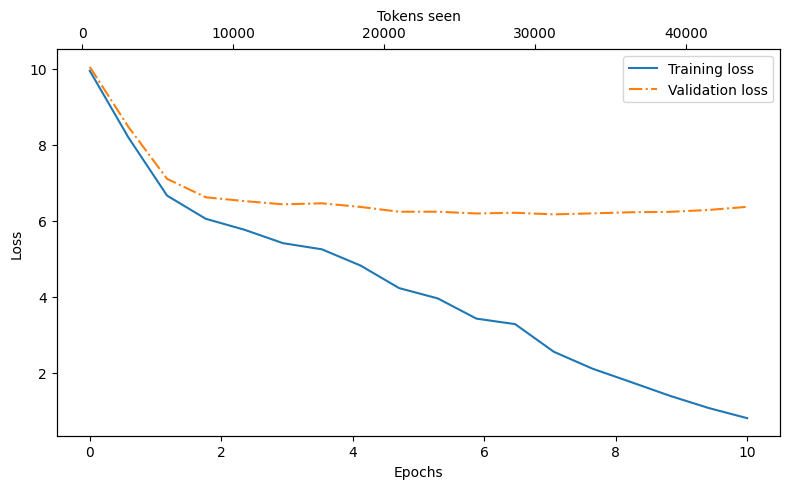

In [47]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator


def plot_losses(epochs_seen, tokens_seen, train_losses, val_losses):
    fig, ax1 = plt.subplots(figsize=(8, 5))

    # Plot training and validation loss against epochs
    ax1.plot(epochs_seen, train_losses, label="Training loss")
    ax1.plot(epochs_seen, val_losses, linestyle="-.", label="Validation loss")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Loss")
    ax1.legend(loc="upper right")
    ax1.xaxis.set_major_locator(MaxNLocator(integer=True))  # only show integer labels on x-axis

    # Create a second x-axis for tokens seen
    ax2 = ax1.twiny()  # Create a second x-axis that shares the same y-axis
    ax2.plot(tokens_seen, train_losses, alpha=0)  # Invisible plot for aligning ticks
    ax2.set_xlabel("Tokens seen")

    fig.tight_layout()  # Adjust layout to make room
    plt.savefig("loss-plot.pdf")
    plt.show()

epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
plot_losses(epochs_tensor, tokens_seen, train_losses, val_losses)

**From the plot above:**

- At the beginning of the training, we observe that both the training and validation set losses sharply decrease, which is a sign that the model is learning.

- However, the training set loss continues to decrease past the second epoch, whereas the validation loss stagnates. This is a sign that the model is still learning, but it's overfitting to the training set past epoch 2.

- This divergence and the fact that the validation loss is much larger than the training loss indicate that the model is overfitting to the training data.

- The model memorizes the training data verbatim by searching for the generated text snippets, such as `"quite insensible to the irony"` in the `"The Verdict"` text file.

- This memorization is expected since we are working with a very, very small training dataset and training the model for multiple epochs. Usually, it's common to train a model on a much, much larger dataset for only one epoch.


![Alt text](../../assests/figure513.png)


- The next section will cover text generation strategies for LLM to reduce training data memorization and increase the originality of the LLM-generated text before we cover weight loading and saving and loading pretrained weights from `OpenAI's` GPT model.

## **3. Decoding strategies to control randomness**


- Inference is relatively cheap with a relatively small LLM as the GPT model we trained above, so there's no need to use a GPU for it in case you used a GPU for training it above.

- Using the `generate_text_simple` function (from the previous chapter) that we used earlier inside the simple training function, we can generate new text one word (or token) at a time.

- The next generated token is the token corresponding to the largest probability score among all tokens in the vocabulary.

In [48]:
model.to("cpu")
model.eval()

tokenizer = tiktoken.get_encoding("gpt2")

token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids("Every effort moves you", tokenizer),
    max_new_tokens=25,
    context_size=GPT_CONFIG_124M["context_length"]
)

print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves you?"

"Yes--quite insensible to the irony. She wanted him vindicated--and by me!"




- Even if we execute the `generate_text_simple` function above multiple times, the LLM will always generate the same outputs.

- We now introduce two concepts, so-called decoding strategies, to modify the generate_text_simple: *temperature scaling* and *top-k sampling*.

- These will allow the model to control the randomness and diversity of the generated text.

#### **Temperature scaling**


- This section introduces `temperature scaling`, a technique that adds a probabilistic selection process to the next-token generation task.

- Previously, we always sampled the token with the highest probability as the next token using `torch.argmax`, also known as *greedy decoding*.

- To generate text with more variety, we can sample the next token using The `torch.multinomial(probs, num_samples=1)`, sampling from a probability distribution.

- Here, each index's chance of being picked corresponds to its probability in the input tensor.

- Here's a little recap of generating the next token, assuming a very small vocabulary for illustration purposes:

In [58]:
vocab = { 
    "closer": 0,
    "every": 1, 
    "effort": 2, 
    "forward": 3,
    "inches": 4,
    "moves": 5, 
    "pizza": 6,
    "toward": 7,
    "you": 8,
} 

inverse_vocab = {v: k for k, v in vocab.items()}

# Suppose input is "every effort moves you", and the LLM
# returns the following logits for the next token:
next_token_logits = torch.tensor(
    [4.51, 0.89, -1.90, 6.75, 1.63, -1.62, -1.89, 6.28, 1.79]
)

probas = torch.softmax(next_token_logits, dim=0)
next_token_id = torch.argmax(probas).item()

# The next generated token is then as follows:
print(inverse_vocab[next_token_id])

forward


In [59]:
torch.manual_seed(123)
next_token_id = torch.multinomial(probas, num_samples=1).item()
print(inverse_vocab[next_token_id])

forward


- Instead of determining the most likely token via `torch.argmax`, we use `torch.multinomial(probas, num_samples=1)` to determine the most likely token by sampling from the softmax distribution.

- For illustration purposes, let's see what happens when we sample the next token 1,000 times using the original softmax probabilities:

In [64]:
def print_sampled_tokens(probas):
    torch.manual_seed(123) # Manual seed for reproducibility
    sample = [torch.multinomial(probas, num_samples=1).item() for i in range(1_000)]
    sampled_ids = torch.bincount(torch.tensor(sample), minlength=len(probas))
    for i, freq in enumerate(sampled_ids):
        print(f"{freq} x {inverse_vocab[i]}")

print_sampled_tokens(probas)

73 x closer
0 x every
0 x effort
582 x forward
2 x inches
0 x moves
0 x pizza
343 x toward
0 x you


- Based on the output, the word `forward` is sampled most of the time (`582` out of 1000 times), but other tokens such as `"closer"`, `"inches"`, and `"toward"` will also be sampled some of the time.

- This means that if we replaced the `argmax` function with the `multinomial` function inside the `generate_and_print_sample` function, the LLM would sometimes generate texts such as `"every effort moves you toward"`, `"every effort moves you inches"`, and `"every effort moves you closer"` instead of `"every effort moves you forward"`.


- We can further control the distribution and selection process via a concept called `temperature scaling`.

- `Temperature scaling` is just a fancy description for dividing the logits by a number greater than 0.

- Temperatures greater than 1 will result in more uniformly distributed token probabilities after applying the softmax.

- Temperatures smaller than 1 will result in more confident (sharper or more peaky) distributions after applying the softmax.

In [65]:
def softmax_with_temperature(logits, temperature):
    scaled_logits = logits / temperature
    return torch.softmax(scaled_logits, dim=0)

# Temperature values
temperatures = [1, 0.1, 5]  # Original, higher confidence, and lower confidence

# Calculate scaled probabilities
scaled_probas = [softmax_with_temperature(next_token_logits, T) for T in temperatures]

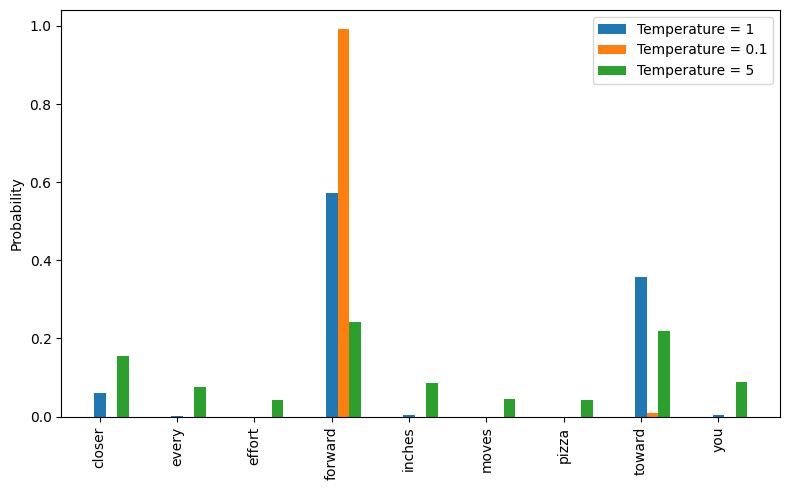

In [67]:
# Plotting
x = torch.arange(len(vocab))
bar_width = 0.15

fig, ax = plt.subplots(figsize=(8, 5))
for i, T in enumerate(temperatures):
    rects = ax.bar(x + i * bar_width, scaled_probas[i], bar_width, label=f'Temperature = {T}')

ax.set_ylabel('Probability')
ax.set_xticks(x)
ax.set_xticklabels(vocab.keys(), rotation=90)
ax.legend()

plt.tight_layout()
plt.savefig("temperature-plot.pdf")
plt.show()

- From the plot above, the temperature of `1` represents the unscaled probability scores for each token in the vocabulary. Decreasing the temperature to `0.1` sharpens the distribution, so the most likely token (here, `"forward"`) will have an even higher probability score. Vice versa, increasing the temperature to `5` make the distribution more uniform.

- A temperature of `1` divides the logits by 1 before passing them to the `softmax` function to compute the probability scores. Using a temperature of `1` is the same as not using any temperature scaling. In this case, the tokens are selected with a probability equal to the original softmax probability scores via the `multinomial` sampling function in PyTorch.


In [68]:
print_sampled_tokens(scaled_probas[1])

0 x closer
0 x every
0 x effort
985 x forward
0 x inches
0 x moves
0 x pizza
15 x toward
0 x you


- The rescaled probabilities via temperature 5 are more uniformly distributed:

In [69]:
print_sampled_tokens(scaled_probas[2])

165 x closer
75 x every
42 x effort
239 x forward
71 x inches
46 x moves
32 x pizza
227 x toward
103 x you


- Assuming an LLM input "every effort moves you", using the approach above can sometimes result in nonsensical texts, such as "every effort moves you pizza", 3.2% of the time (32 out of 1000 times)

**Top-k sampling**

- In this section, we introduce another concept called *top-k sampling*, which, when combined with probabilistic sampling and temperature scaling, can improve the text generation results.

- In *top-k sampling*, we can restrict the sampled tokens to the top-k most likely tokens and exclude all other tokens from the selection process by masking their probability scores.

- To be able to use higher temperatures to increase output diversity and to reduce the probability of nonsensical sentences, we can restrict the sampled tokens to the top-k most likely tokens:

![Alt text](../../assests/figure515.png)


- Using *top-k sampling* with `k=3`, we focus on the `3` tokens associated with the highest logits and mask out all other tokens with negative infinity (-inf) before applying the `softmax` function. This results in a probability distribution with a probability value `0` assigned to all non-top-k tokens.

- The approach outlined in the Figure above replaces all non-selected logits with negative infinity value (-inf), such that when computing the softmax values, the probability scores of the non-top-k tokens are 0, and the remaining probabilities sum up to `1`. 

- In code, we can implement the top-k procedure outlined in the figure above as follows, starting with the selection of the tokens with the largest logit values.

In [70]:
top_k = 3
top_logits, top_pos = torch.topk(next_token_logits, top_k)

print("Top logits:", top_logits)
print("Top positions:", top_pos)

Top logits: tensor([6.7500, 6.2800, 4.5100])
Top positions: tensor([3, 7, 0])


In [72]:
top_logits[-1]

tensor(4.5100)

In [73]:
new_logits = torch.where(
    condition=next_token_logits < top_logits[-1],
    input=torch.tensor(float("-inf")), 
    other=next_token_logits
)

print(new_logits)

tensor([4.5100,   -inf,   -inf, 6.7500,   -inf,   -inf,   -inf, 6.2800,   -inf])


- An alternative, slightly more efficient implementation of the previous code cell is the following:

In [75]:
new_logits = torch.full_like( # create tensor containing -inf values
   next_token_logits, -torch.inf
)   
new_logits[top_pos] = next_token_logits[top_pos] # copy top k values into the -inf tensor
print(new_logits)

tensor([4.5100,   -inf,   -inf, 6.7500,   -inf,   -inf,   -inf, 6.2800,   -inf])


- Lastly, let's apply the `softmax` function to turn these into next-token probabilities:

In [76]:
topk_probas = torch.softmax(new_logits, dim=0)
print(topk_probas)

tensor([0.0615, 0.0000, 0.0000, 0.5775, 0.0000, 0.0000, 0.0000, 0.3610, 0.0000])


**Modifying the text generation function**

- The previous two subsections introduced temperature sampling and top-k sampling

- Let's use these two concepts to modify the `generate_simple` function we used to generate text via the LLM earlier, creating a new `generate` function:

In [77]:
def generate(model, idx, max_new_tokens, context_size, temperature=0.0, top_k=None, eos_id=None):

    # For-loop is the same as before: Get logits, and only focus on last time step
    for _ in range(max_new_tokens):
        idx_cond = idx[:, -context_size:]
        with torch.no_grad():
            logits = model(idx_cond)
        logits = logits[:, -1, :]

        # New: Filter logits with top_k sampling
        if top_k is not None:
            # Keep only top_k values
            top_logits, _ = torch.topk(logits, top_k)
            min_val = top_logits[:, -1]
            logits = torch.where(logits < min_val, torch.tensor(float("-inf")).to(logits.device), logits)

        # New: Apply temperature scaling
        if temperature > 0.0:
            logits = logits / temperature

            # Apply softmax to get probabilities
            probs = torch.softmax(logits, dim=-1)  # (batch_size, context_len)

            # Sample from the distribution
            idx_next = torch.multinomial(probs, num_samples=1)  # (batch_size, 1)

        # Otherwise same as before: get idx of the vocab entry with the highest logits value
        else:
            idx_next = torch.argmax(logits, dim=-1, keepdim=True)  # (batch_size, 1)

        if idx_next == eos_id:  # Stop generating early if end-of-sequence token is encountered and eos_id is specified
            break

        # Same as before: append sampled index to the running sequence
        idx = torch.cat((idx, idx_next), dim=1)  # (batch_size, num_tokens+1)

    return idx

In [92]:
torch.manual_seed(123)

token_ids = generate(
    model=model,
    idx=text_to_token_ids("Every effort moves you", tokenizer),
    max_new_tokens=15,
    context_size=GPT_CONFIG_124M["context_length"],
    top_k=25,
    temperature=1.4
)

print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves you?" I meant to do the sketch of his glory, so a little



- As we can see, the generated text is very different from the one we previously generated via the `generate_simple` function.

## **4. Loading and saving model weights in PyTorch**

- Training LLMs is computationally expensive, so it's crucial to be able to save and load LLM weights.

![Alt text](../../assests/figure516.png)


- After training and inspecting the model, it is often helpful to save the model so that we can use or continue training it later.

- The recommended way in PyTorch is to save the model weights, the so-called `state_dict` via by applying the `torch.save` function to the `.state_dict()` method:


In [93]:
torch.save(model.state_dict(), "model.pth")

- Then, after saving the model weights via the `state_dict`, we can load the model weights into a new `GPTModel` model instance as follows:

In [94]:
model = GPTModel(GPT_CONFIG_124M)
device = torch.device("cuda" if torch.cuda.is_available() else "mps")
model.load_state_dict(torch.load("model.pth", map_location=device, weights_only=True))
model.eval();

- If we plan to continue pretraining a model later, for example, using the `train_model_simple` function we defined earlier in this section, saving the optimizer state is also recommended.

- It's common to train LLMs with adaptive optimizers like `Adam` or `AdamW` instead of regular `SGD`.

- `AdamW` uses historical data to adjust learning rates for each model parameter dynamically. Without it, the optimizer resets, and the model may learn suboptimally or even fail to converge properly, which means that it will lose the ability to generate coherent text. 

- These adaptive optimizers store additional parameters for each model weight, so it makes sense to save them as well in case we plan to continue the pretraining later.

- Using `torch.save`, we can save both the model and optimizer state_dict contents as follows:

In [96]:
torch.save({
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    }, 
    "model_and_optimizer.pth"
)

- Then, we can restore the model and optimizer states as follows by first loading the saved data via `torch.load` and then using the `load_state_dict` method:

In [97]:
checkpoint = torch.load("model_and_optimizer.pth", weights_only=True)

model = GPTModel(GPT_CONFIG_124M)
model.load_state_dict(checkpoint["model_state_dict"])

optimizer = torch.optim.AdamW(model.parameters(), lr=0.0005, weight_decay=0.1)
optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
model.train();

## **5. Loading pretrained weights from OpenAI**

- Previously, we only trained a small `GPT-2` model using a very small short-story book for educational purposes.

- Fortunately, we don't have to spend tens to hundreds of thousands of dollars to pretrain the model on a large pretraining corpus but can load the pretrained weights provided by OpenAI.

- In the remainder of this section, we load these weights into our GPTModel class and use the model for text generation. Here, weights refer to the weight parameters that are stored in the `.weight` attributes of PyTorch's Linear and Embedding layers, for example. We accessed them earlier via `model.parameters()` when training the model.

- First, some boilerplate code to download the files from OpenAI and load the weights into Python
- Since OpenAI used TensorFlow, we will have to install and use TensorFlow for loading the weights; tqdm is a progress bar library

In [98]:
print("TensorFlow version:", version("tensorflow"))
print("tqdm version:", version("tqdm"))

TensorFlow version: 2.20.0
tqdm version: 4.67.1


In [99]:
# Relative import from the gpt_download.py contained in this folder

from gpt_download import download_and_load_gpt2

- We can then download the model `weights` for the `124` million parameter model as follows:

In [100]:
settings, params = download_and_load_gpt2(model_size="124M", models_dir="gpt2")

checkpoint: 100%|██████████| 77.0/77.0 [00:00<00:00, 3.88kiB/s]
encoder.json: 100%|██████████| 1.04M/1.04M [00:03<00:00, 315kiB/s] 
hparams.json: 100%|██████████| 90.0/90.0 [00:00<00:00, 42.9kiB/s]
model.ckpt.data-00000-of-00001: 100%|██████████| 498M/498M [04:32<00:00, 1.83MiB/s]   
model.ckpt.index: 100%|██████████| 5.21k/5.21k [00:00<00:00, 2.79MiB/s]
model.ckpt.meta: 100%|██████████| 471k/471k [00:01<00:00, 444kiB/s]  
vocab.bpe: 100%|██████████| 456k/456k [00:01<00:00, 334kiB/s]  


- After the execution of the previous code has been completed, let's inspect the contents of
settings and params:

In [101]:
print("Settings:", settings)

Settings: {'n_vocab': 50257, 'n_ctx': 1024, 'n_embd': 768, 'n_head': 12, 'n_layer': 12}


In [102]:
print("Parameter dictionary keys:", params.keys())

Parameter dictionary keys: dict_keys(['blocks', 'b', 'g', 'wpe', 'wte'])


Both `settings` and `params` are Python dictionaries. The settings dictionary stores the LLM architecture settings similarly to our manually defined `GPT_CONFIG_124M` settings. The params dictionary contains the actual weight tensors. Note that we only printed the dictionary keys because printing the weight contents would take up too much screen space, however, we can inspect these weight tensors by printing the whole dictionary via `print(params)` or by selecting individual tensors via the respective dictionary keys, for example, the embedding layer `weights`:

In [103]:
print(params["wte"])
print("Token embedding weight tensor dimensions:", params["wte"].shape)

[[-0.11010301 -0.03926672  0.03310751 ... -0.1363697   0.01506208
   0.04531523]
 [ 0.04034033 -0.04861503  0.04624869 ...  0.08605453  0.00253983
   0.04318958]
 [-0.12746179  0.04793796  0.18410145 ...  0.08991534 -0.12972379
  -0.08785918]
 ...
 [-0.04453601 -0.05483596  0.01225674 ...  0.10435229  0.09783269
  -0.06952604]
 [ 0.1860082   0.01665728  0.04611587 ... -0.09625227  0.07847701
  -0.02245961]
 [ 0.05135201 -0.02768905  0.0499369  ...  0.00704835  0.15519823
   0.12067825]]
Token embedding weight tensor dimensions: (50257, 768)


- Alternatively, `"355M"`, `"774M"`, and `"1558M"` are also supported model_size arguments.

- The difference between these differently sized models is summarized in the figure below:

![Alt text](../../assests/figure517.png)

- Above, we loaded the 124M GPT-2 model weights into Python, however we still need to transfer them into our `GPTModel` instance.
  
- First, we initialize a new `GPTModel` instance
  
- Note that the original GPT model initialized the linear layers for the query, key, and value matrices in the multi-head attention module with bias vectors, which is not required or recommended; however, to be able to load the weights correctly, we have to enable these too by setting `qkv_bias` to `True` in our implementation, too
  
- We are also using the `1024` token context length that was used by the original GPT-2 model(s)

In [104]:
# Define model configurations in a dictionary for compactness
model_configs = {
    "gpt2-small (124M)": {"emb_dim": 768, "n_layers": 12, "n_heads": 12},
    "gpt2-medium (355M)": {"emb_dim": 1024, "n_layers": 24, "n_heads": 16},
    "gpt2-large (774M)": {"emb_dim": 1280, "n_layers": 36, "n_heads": 20},
    "gpt2-xl (1558M)": {"emb_dim": 1600, "n_layers": 48, "n_heads": 25},
}

# Copy the base configuration and update with specific model settings
model_name = "gpt2-small (124M)"  # Example model name
NEW_CONFIG = GPT_CONFIG_124M.copy()
NEW_CONFIG.update(model_configs[model_name])
NEW_CONFIG.update({"context_length": 1024, "qkv_bias": True})

gpt = GPTModel(NEW_CONFIG)
gpt.eval();

- The next task is to assign the OpenAI weights to the corresponding weight tensors in our `GPTModel` instance

- For this, we will first define a small `assign` utility function that checks whether two tensors or arrays (left and right) have the same dimensions or shape and returns the right tensor as trainable PyTorch parameters:

In [105]:
def assign(left, right):
    if left.shape != right.shape:
        raise ValueError(f"Shape mismatch. Left: {left.shape}, Right: {right.shape}")
    return torch.nn.Parameter(torch.tensor(right))

In [106]:
import numpy as np

def load_weights_into_gpt(gpt, params):
    gpt.pos_emb.weight = assign(gpt.pos_emb.weight, params['wpe'])
    gpt.tok_emb.weight = assign(gpt.tok_emb.weight, params['wte'])
    
    for b in range(len(params["blocks"])):
        q_w, k_w, v_w = np.split(
            (params["blocks"][b]["attn"]["c_attn"])["w"], 3, axis=-1)
        gpt.trf_blocks[b].att.W_query.weight = assign(
            gpt.trf_blocks[b].att.W_query.weight, q_w.T)
        gpt.trf_blocks[b].att.W_key.weight = assign(
            gpt.trf_blocks[b].att.W_key.weight, k_w.T)
        gpt.trf_blocks[b].att.W_value.weight = assign(
            gpt.trf_blocks[b].att.W_value.weight, v_w.T)

        q_b, k_b, v_b = np.split(
            (params["blocks"][b]["attn"]["c_attn"])["b"], 3, axis=-1)
        gpt.trf_blocks[b].att.W_query.bias = assign(
            gpt.trf_blocks[b].att.W_query.bias, q_b)
        gpt.trf_blocks[b].att.W_key.bias = assign(
            gpt.trf_blocks[b].att.W_key.bias, k_b)
        gpt.trf_blocks[b].att.W_value.bias = assign(
            gpt.trf_blocks[b].att.W_value.bias, v_b)

        gpt.trf_blocks[b].att.out_proj.weight = assign(
            gpt.trf_blocks[b].att.out_proj.weight, 
            params["blocks"][b]["attn"]["c_proj"]["w"].T)
        gpt.trf_blocks[b].att.out_proj.bias = assign(
            gpt.trf_blocks[b].att.out_proj.bias, 
            params["blocks"][b]["attn"]["c_proj"]["b"])

        gpt.trf_blocks[b].ff.layers[0].weight = assign(
            gpt.trf_blocks[b].ff.layers[0].weight, 
            params["blocks"][b]["mlp"]["c_fc"]["w"].T)
        gpt.trf_blocks[b].ff.layers[0].bias = assign(
            gpt.trf_blocks[b].ff.layers[0].bias, 
            params["blocks"][b]["mlp"]["c_fc"]["b"])
        gpt.trf_blocks[b].ff.layers[2].weight = assign(
            gpt.trf_blocks[b].ff.layers[2].weight, 
            params["blocks"][b]["mlp"]["c_proj"]["w"].T)
        gpt.trf_blocks[b].ff.layers[2].bias = assign(
            gpt.trf_blocks[b].ff.layers[2].bias, 
            params["blocks"][b]["mlp"]["c_proj"]["b"])

        gpt.trf_blocks[b].norm1.scale = assign(
            gpt.trf_blocks[b].norm1.scale, 
            params["blocks"][b]["ln_1"]["g"])
        gpt.trf_blocks[b].norm1.shift = assign(
            gpt.trf_blocks[b].norm1.shift, 
            params["blocks"][b]["ln_1"]["b"])
        gpt.trf_blocks[b].norm2.scale = assign(
            gpt.trf_blocks[b].norm2.scale, 
            params["blocks"][b]["ln_2"]["g"])
        gpt.trf_blocks[b].norm2.shift = assign(
            gpt.trf_blocks[b].norm2.shift, 
            params["blocks"][b]["ln_2"]["b"])

    gpt.final_norm.scale = assign(gpt.final_norm.scale, params["g"])
    gpt.final_norm.shift = assign(gpt.final_norm.shift, params["b"])
    gpt.out_head.weight = assign(gpt.out_head.weight, params["wte"])
    
    
load_weights_into_gpt(gpt, params)
gpt.to(device);

- In the `load_weights_into_gpt` function, we carefully match the weights from OpenAI's implementation with our GPTModel implementation. To pick a specific example, OpenAI stored the weight tensor for the output projection layer for the first transformer block as `params["blocks"][0]["attn"]["c_proj"]["w"]`. In our implementation, this weight tensor corresponds to `gpt.trf_blocks[b].att.out_proj.weight`, where gpt is a GPTModel instance.

- If the model is loaded correctly, we can use it to generate new text using our previous `generate` function:

In [112]:
torch.manual_seed(123)

token_ids = generate(
    model=gpt,
    idx=text_to_token_ids("Every effort moves you", tokenizer).to(device),
    max_new_tokens=50,
    context_size=NEW_CONFIG["context_length"],
    top_k=50,
    temperature=1.5
)

print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves you toward more efficient and efficient processes, like in the car's oil and gas operation," the study said. To see if that leads to greater benefit from building on what will help people most benefit, the research analyzed how individuals would have felt at each stage


- We can be confident that we loaded the model weights correctly because the model can produce coherent text. A tiny mistake in this process would cause the model to fail.